In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
w = np.linspace(-4,4,100)
loss = w**2
slope = 2*w

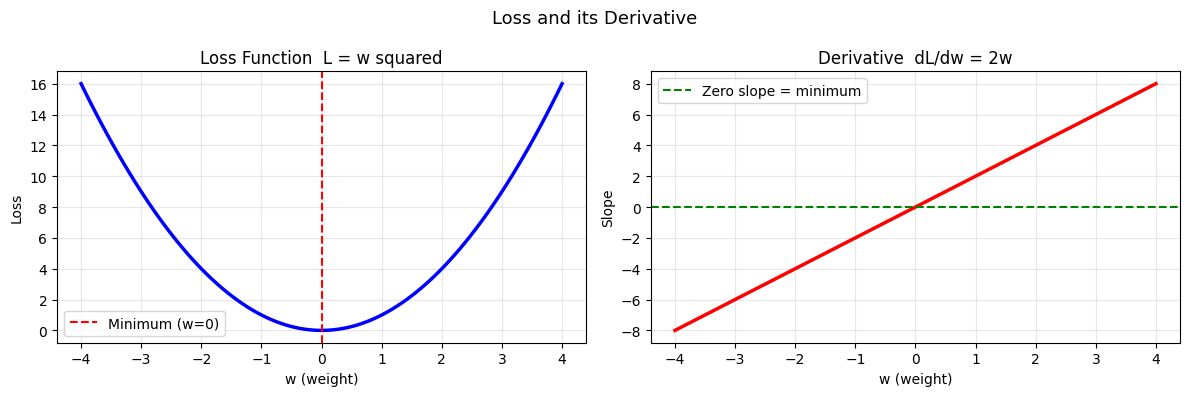

At w=3:  slope = 6 → too high, move left
At w=-2: slope = -4 → too low,  move right
At w=0:  slope = 0 → minimum!  stop here


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Loss function: L = w squared
w      = np.linspace(-4, 4, 100)
loss   = w ** 2
slope  = 2 * w      # derivative of w squared = 2w

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss curve
axes[0].plot(w, loss, 'b-', linewidth=2.5)
axes[0].set_title('Loss Function  L = w squared')
axes[0].set_xlabel('w (weight)')
axes[0].set_ylabel('Loss')
axes[0].axvline(0, color='red', linestyle='--', label='Minimum (w=0)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Derivative (slope)
axes[1].plot(w, slope, 'r-', linewidth=2.5)
axes[1].set_title('Derivative  dL/dw = 2w')
axes[1].set_xlabel('w (weight)')
axes[1].set_ylabel('Slope')
axes[1].axhline(0, color='green', linestyle='--', label='Zero slope = minimum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss and its Derivative', fontsize=13)
plt.tight_layout()
plt.show()

# Notice:
# Left plot:  U shape, lowest point at w=0
# Right plot: Line, crosses zero at w=0
# Zero crossing on derivative = minimum on loss curve
# Training finds this zero crossing automatically
print("At w=3:  slope =", 2*3,  "→ too high, move left")
print("At w=-2: slope =", 2*-2, "→ too low,  move right")
print("At w=0:  slope =", 2*0,  "→ minimum!  stop here")

## Random Forest Deep Dive 

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [6]:
# data = load_breast_cancer()
# data

In [3]:
X,y = load_breast_cancer(return_X_y=True)

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== Single Tree vs Random Forest ===\n")

# Single Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_train = dt.score(X_train, y_train)
dt_test  = dt.score(X_test,  y_test)
print(f"Single Tree:   train={dt_train:.3f}  test={dt_test:.3f}")
print(f"               gap={dt_train - dt_test:.3f}  ← overfitting!")

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_train = rf.score(X_train, y_train)
rf_test  = rf.score(X_test,  y_test)
print(f"\nRandom Forest: train={rf_train:.3f}  test={rf_test:.3f}")
print(f"               gap={rf_train - rf_test:.3f}  ← much less overfit!")

print("""
Why Random Forest is better:
→ Trains 100 different trees
→ Each tree sees random subset of data
→ Each tree uses random subset of features
→ Final answer = majority vote from all trees
→ One tree can be wrong, 100 trees rarely wrong
   Like asking 100 doctors vs 1 doctor
""")

=== Single Tree vs Random Forest ===

Single Tree:   train=1.000  test=0.939
               gap=0.061  ← overfitting!

Random Forest: train=1.000  test=0.965
               gap=0.035  ← much less overfit!

Why Random Forest is better:
→ Trains 100 different trees
→ Each tree sees random subset of data
→ Each tree uses random subset of features
→ Final answer = majority vote from all trees
→ One tree can be wrong, 100 trees rarely wrong
   Like asking 100 doctors vs 1 doctor



###  Effect of number of trees:

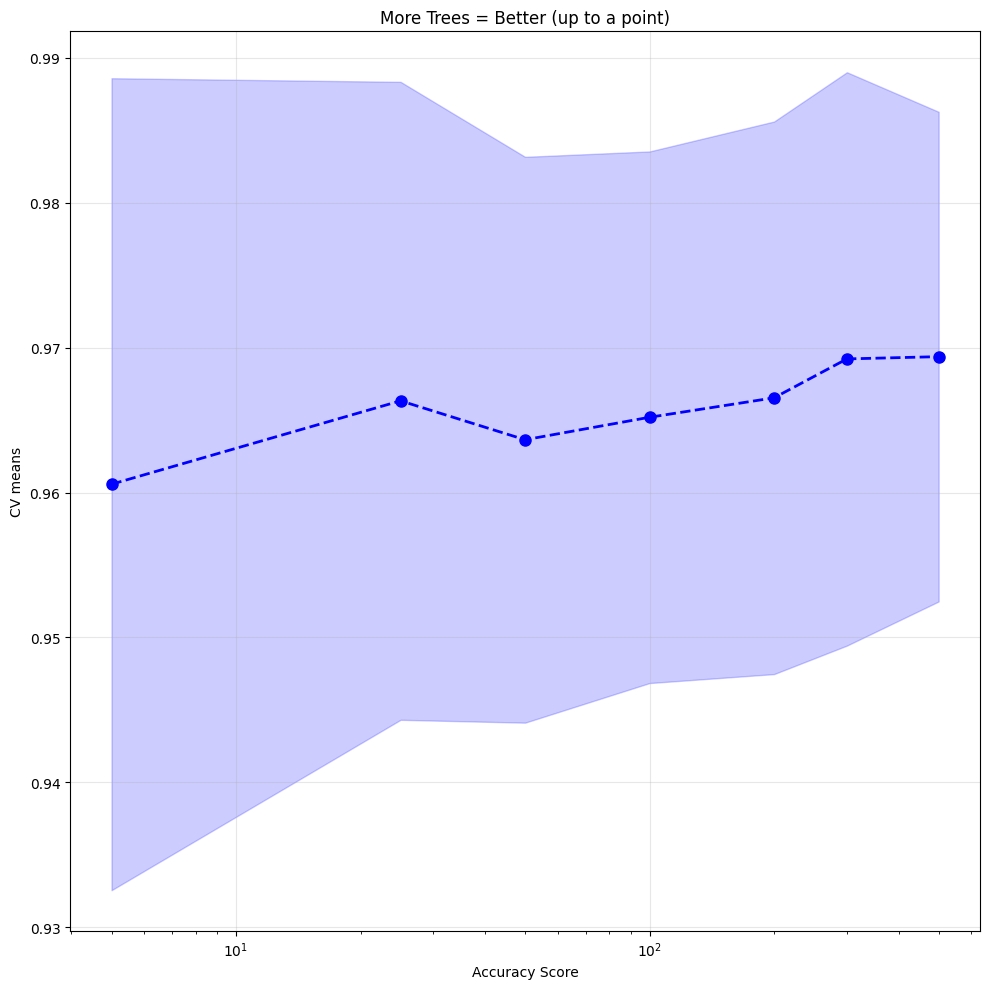

In [35]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
no_of_trees = [5,25,50,100,200,300,500]

score_mean = []
score_std = []
for n in no_of_trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X, y, cv=5, scoring="f1")
    score_mean.append(score.mean())
    score_std.append(score.std())

plt.figure(figsize=(10,10))
plt.plot(no_of_trees, score_mean, "b--o", linewidth=2, markersize=8)
plt.fill_between(no_of_trees,
                 [m-s for m, s in zip(score_mean, score_std)],
                 [m+s for m, s in zip(score_mean, score_std)],
                 alpha=0.2, color='blue')
plt.xlabel("Accuracy Score")
plt.ylabel("CV means")
plt.title('More Trees = Better (up to a point)')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
    

### Key parameters explained:

In [38]:
print("""
PARAMETER GUIDE:
================

n_estimators = number of trees
   Default: 100
   More = better but slower
   Sweet spot: 100-200

max_depth = how deep each tree grows
   Default: None (fully grown)
   Lower = less overfit but might underfit
   Try: None, 5, 10, 15

max_features = features each tree considers
   Default: sqrt(total features)
   This is what makes trees different from each other
   Do not change this usually

min_samples_split = min samples to split a node
   Default: 2
   Higher = simpler trees = less overfit
   Try: 2, 5, 10

random_state = for reproducibility
   Always set this to 42 or any number
   Without it: different results every run
""")
from sklearn.metrics import f1_score
config = [
    {"n_estimators":100, "max_depth":None},
    {"n_estimators":100, "max_depth":5},
    {"n_estimators":200, "max_depth":None},
    {"n_estimators":100, "max_depth":10},
]

for cfg in config:
    model_rf = RandomForestClassifier(**cfg, random_state=42)
    model_rf.fit(X_train,y_train)
    preds = model_rf.predict(X_test)
    f1 = f1_score(preds,y_test)

    print(f"for config {cfg} score is {f1}")


PARAMETER GUIDE:

n_estimators = number of trees
   Default: 100
   More = better but slower
   Sweet spot: 100-200

max_depth = how deep each tree grows
   Default: None (fully grown)
   Lower = less overfit but might underfit
   Try: None, 5, 10, 15

max_features = features each tree considers
   Default: sqrt(total features)
   This is what makes trees different from each other
   Do not change this usually

min_samples_split = min samples to split a node
   Default: 2
   Higher = simpler trees = less overfit
   Try: 2, 5, 10

random_state = for reproducibility
   Always set this to 42 or any number
   Without it: different results every run

for config {'n_estimators': 100, 'max_depth': None} score is 0.9722222222222222
for config {'n_estimators': 100, 'max_depth': 5} score is 0.9722222222222222
for config {'n_estimators': 200, 'max_depth': None} score is 0.9722222222222222
for config {'n_estimators': 100, 'max_depth': 10} score is 0.9722222222222222


## Employee Churn Predictor 

In [49]:
import pandas as pd
import numpy as np
np.random.seed(42)
n=1000
# building dummy data

df =pd.DataFrame({
   'age'            : np.random.randint(22, 60, n),
    'salary'         : np.random.randint(30000, 150000, n),
    'years_at_co'    : np.random.randint(0, 20, n),
    'satisfaction'   : np.random.uniform(0, 10, n).round(1),
    'dept'           : np.random.choice(['Eng','Sales','HR','Finance'], n),
    'overtime'       : np.random.choice([0, 1], n, p=[0.6, 0.4]),
    'promotions'     : np.random.randint(0, 5, n),
    'distance_home'  : np.random.randint(1, 60, n),
})

df["churned"] = (
    (df['satisfaction']<4) |
    ((df['years_at_co']>10) & (df['promotions']==0)) |
    ((df['salary']<50000) & (df['overtime']==1))
).astype(int)

print(f"shape of the df {df.shape}")
print(df.info)
print(df["churned"].mean())

churn_by_dept = df.groupby('dept')["churned"].mean()
print(churn_by_dept)

churn_by_years_at_co = df.groupby('years_at_co')['churned'].mean()
print(churn_by_years_at_co)


shape of the df (1000, 9)
<bound method DataFrame.info of      age  salary  years_at_co  satisfaction     dept  overtime  promotions  \
0     50   32717           19           3.0       HR         0           1   
1     36   89676           17           8.3      Eng         0           0   
2     29   57952           13           2.8      Eng         0           0   
3     42  116444            1           8.7       HR         0           4   
4     40   72460            8           1.1  Finance         0           4   
..   ...     ...          ...           ...      ...       ...         ...   
995   34  113310           19           1.6  Finance         0           1   
996   51   97278           12           6.7       HR         0           1   
997   44   48309            6           1.8  Finance         0           3   
998   40   30619           13           6.9    Sales         1           1   
999   53  113194            8           2.3       HR         0           2   

     

### Feature engineering:

In [64]:
# Feature engineering = create new meaningful features
# This is where your data engineering background shines!

print("New features created:")
new_features = ['salary_per_year', 'is_underpaid',
                'low_satisfaction', 'no_growth',
                'high_overtime_low_pay']

df["salary_per_year"] = df['salary']/(df['years_at_co']+1)
df["is_underpaid"] = ((df["years_at_co"]>5) & (df["salary"]<50000)).astype(int)
df['low_satisfaction'] = (df['satisfaction'] < 4).astype(int)
df['no_growth']        = (
    (df['promotions'] == 0) & (df['years_at_co'] > 3)
).astype(int)
df['high_overtime_low_pay'] = (
    (df['overtime'] == 1) & (df['salary'] < 60000)
).astype(int)

from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df["dept"] = enc.fit_transform(df["dept"])

print(df[new_features].head(5).round(2))

New features created:
   salary_per_year  is_underpaid  low_satisfaction  no_growth  \
0          1635.85             1                 1          0   
1          4982.00             0                 0          1   
2          4139.43             0                 1          1   
3         58222.00             0                 0          0   
4          8051.11             0                 1          0   

   high_overtime_low_pay  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


In [73]:
corr = df.corr()["churned"].abs().sort_values(ascending=False)
imp_features = corr[corr>0.020]
# print(imp_features)
imp_cols = [col for col in imp_features.keys() if col!= "churned"]
imp_cols

['low_satisfaction',
 'satisfaction',
 'no_growth',
 'promotions',
 'high_overtime_low_pay',
 'salary',
 'is_underpaid',
 'salary_per_year',
 'years_at_co',
 'age',
 'overtime',
 'distance_home']

In [74]:
X = df[imp_cols]
y = df["churned"]

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

features = ['age', 'salary', 'years_at_co', 'satisfaction',
            'overtime', 'promotions', 'distance_home',
            'salary_per_year', 'is_underpaid',
            'low_satisfaction', 'no_growth',
            'high_overtime_low_pay', 'dept']

X = df[features]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

print("=== Churn Prediction Results ===\n")
print(classification_report(
    y_test, rf.predict(X_test),
    target_names=['Stayed', 'Churned']
))

# Cross validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='recall')
print(f"CV Recall: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("(Recall = how many churners we correctly caught)")

=== Churn Prediction Results ===

              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00       103
     Churned       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

CV Recall: 0.996 ± 0.005
(Recall = how many churners we correctly caught)


## Feature importance chart:

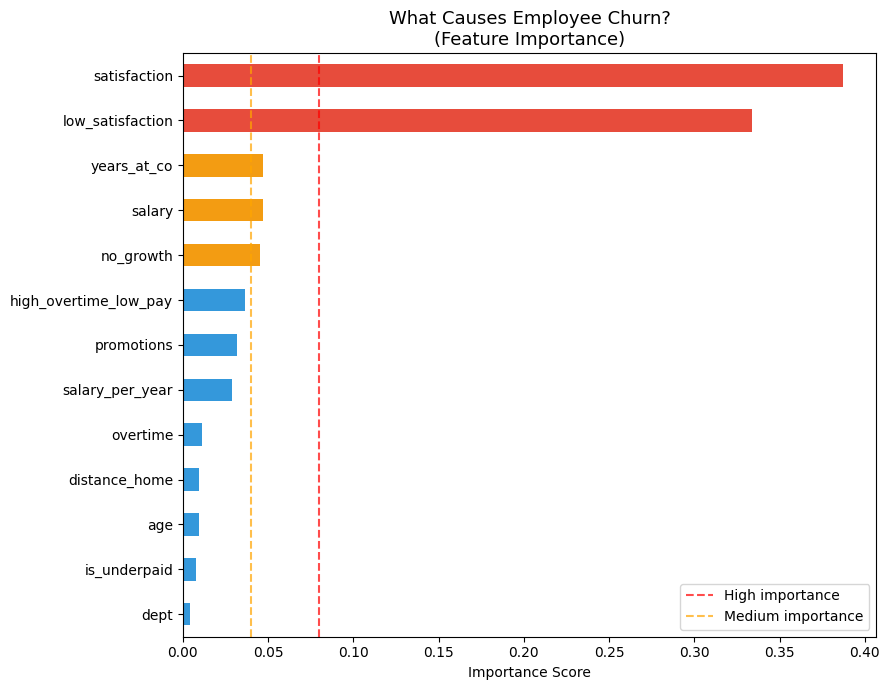


Top 5 churn predictors:
  satisfaction                   0.3874
  low_satisfaction               0.3339
  years_at_co                    0.0469
  salary                         0.0467
  no_growth                      0.0451

Business insight:
→ Focus retention efforts on these features
→ Low satisfaction and overtime are usually top 2


In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance = which features matter most
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#e74c3c' if imp > 0.08 else
          '#f39c12' if imp > 0.04 else
          '#3498db'
          for imp in importance]

importance.plot(kind='barh', color=colors)
plt.title('What Causes Employee Churn?\n(Feature Importance)',
          fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(0.08, color='red',    linestyle='--',
            alpha=0.7, label='High importance')
plt.axvline(0.04, color='orange', linestyle='--',
            alpha=0.7, label='Medium importance')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 churn predictors:")
top5 = importance.sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    print(f"  {feat:30} {imp:.4f}")

print("\nBusiness insight:")
print("→ Focus retention efforts on these features")
print("→ Low satisfaction and overtime are usually top 2")

In [91]:
### checking for one employee

In [106]:
# Predict if a specific employee will churn
# This is what makes ML useful in real business

new_employee = pd.DataFrame({
    'age'                   : [35],
    'salary'                : [80000],
    'years_at_co'           : [8],
    'satisfaction'          : [3.2],    # low satisfaction!
    'overtime'              : [1],      # working overtime!
    'promotions'            : [1],      # no promotions!
    'distance_home'         : [25],
    'salary_per_year'       : [80000/9],
    'is_underpaid'          : [0],
    'low_satisfaction'      : [0],
    'no_growth'             : [0],
    'high_overtime_low_pay' : [0],
    'dept'          : [0],
})

churn_prob  = rf.predict_proba(new_employee)[0][1]
prediction  = rf.predict(new_employee)[0]

print("=== Employee Churn Risk Assessment ===\n")
print(f"Age:           35")
print(f"Salary:        $45,000")
print(f"Years at co:   8")
print(f"Satisfaction:  3.2/10")
print(f"Overtime:      Yes")
print(f"Promotions:    0")
print()
print(f"Churn probability: {churn_prob:.1%}")
print(f"Risk level: {'HIGH RISK' if churn_prob > 0.6 else 'MEDIUM RISK' if churn_prob > 0.3 else 'LOW RISK'}")
print(f"Recommendation: {'Urgent intervention needed!' if churn_prob > 0.6 else 'Monitor closely'}")

# Try changing values yourself:
# What if salary = 80000? Does churn probability drop?
# What if satisfaction = 8.0? How much does it change?
# What if overtime = 0?

=== Employee Churn Risk Assessment ===

Age:           35
Salary:        $45,000
Years at co:   8
Satisfaction:  3.2/10
Overtime:      Yes
Promotions:    0

Churn probability: 54.0%
Risk level: MEDIUM RISK
Recommendation: Monitor closely


np.int64(1)

## Practise on house data 

In [110]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("shree1992/housedata")

print("Path to dataset files:", path)

print(os.listdir(path))
print("Path to dataset files:", path)
import pandas as pd
file_path = os.path.join(path, "data.csv")
output =os.path.join(path, "output.csv")

df = pd.read_csv(file_path)
df_out = pd.read_csv(output)

Path to dataset files: C:\Users\Hp\.cache\kagglehub\datasets\shree1992\housedata\versions\2
['data.csv', 'data.dat', 'output.csv']
Path to dataset files: C:\Users\Hp\.cache\kagglehub\datasets\shree1992\housedata\versions\2


In [154]:
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report


# 1. Target encode high-cardinality columns
for col in ["street", "city", "statezip", "country"]:
    mean_map = df.groupby(col)["price"].mean()
    df[col] = df[col].map(mean_map)

# 2. Log-transform the target
X = df.drop(columns=["price"])
y = np.log1p(df["price"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Remove max_depth restriction
model_rf = RandomForestRegressor(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
model_rf.fit(X_train, y_train)

print("R² score:", model_rf.score(X_test, y_test))


R² score: 0.9960643399527768


In [156]:
proba = model_rf.predict(X_test)

In [158]:
y_pred = np.expm1(proba)

In [161]:

y_pred = model_rf.predict(X_test)

# If you used log transform, reverse it
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

# Side by side comparison
comparison = pd.DataFrame({
    "Actual Price":    y_test_actual.values,
    "Predicted Price": y_pred_actual,
    "Difference":      y_test_actual.values - y_pred_actual,
    "% Error":        ((y_test_actual.values - y_pred_actual) / y_test_actual.values * 100).round(2)
})
print(comparison.head(20))

    Actual Price  Predicted Price    Difference  % Error
0   5.440000e+05     5.440899e+05 -8.988467e+01    -0.02
1   0.000000e+00     0.000000e+00  0.000000e+00      NaN
2   1.712500e+06     1.705476e+06  7.024391e+03     0.41
3   3.650000e+05     3.629738e+05  2.026203e+03     0.56
4   2.750000e+05     2.749173e+05  8.274527e+01     0.03
5   6.250000e+05     6.249875e+05  1.252494e+01     0.00
6   4.530000e+05     4.529013e+05  9.868907e+01     0.02
7   3.000000e+05     3.000000e+05  4.249159e-09     0.00
8   4.179857e+05     4.180460e+05 -6.028471e+01    -0.01
9   6.725000e+05     8.135027e+05 -1.410027e+05   -20.97
10  5.250000e+05     4.252998e+05  9.970019e+04    18.99
11  5.000000e+05     4.999272e+05  7.279774e+01     0.01
12  5.900000e+05     5.900311e+05 -3.112979e+01    -0.01
13  3.050000e+05     3.049522e+05  4.776320e+01     0.02
14  2.100000e+05     2.100299e+05 -2.994143e+01    -0.01
15  9.150000e+05     9.149333e+05  6.667083e+01     0.01
16  6.750000e+05     6.750070e+

C:\Users\Hp\AppData\Local\Temp\ipykernel_4228\747673537.py:12: RuntimeWarning: invalid value encountered in divide
  "% Error":        ((y_test_actual.values - y_pred_actual) / y_test_actual.values * 100).round(2)
